# Payne Zero tutorial

This notebook follows the path from stellar labels to an observed spectrum. You will synthesize light from an existing atmosphere, calculate a new atmosphere, calibrate uncertain atomic line parameters, recover known labels from a mock spectrum, and fit a real Apache Point Observatory Galactic Evolution Experiment (APOGEE) spectrum.

The examples assume an undergraduate-level familiarity with stellar spectra but not with Payne Zero. Each section introduces the physical quantity being calculated before showing the corresponding interface. The same cells run on NVIDIA CUDA, Apple Metal, or a central processing unit (CPU). A CUDA graphics processing unit (GPU) is recommended for the final APOGEE fit; CPU execution follows the same calculation but is slower.

## 1. Imports and device selection

Spectrum synthesis contains many independent wavelength and line-profile calculations, so it benefits strongly from a GPU. The atmosphere calculation has a more ordered iteration and runs on the CPU. The environment variable `PAYNE_ZERO_DEVICE` controls the synthesis device: `cuda` for NVIDIA GPUs, `mps` for Apple Metal, or `cpu`. Without it, the notebook chooses CUDA, then Metal, then CPU.

The tutorial uses NumPy for arrays, PyTorch for accelerated tensor calculations, and Matplotlib for diagnostics. All data and functions used below are included in the public repository.

In [1]:
import json
import os
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

COLORS = {"observed": "#111111", "reference": "#4C78A8", "payne_zero": "#D55E00", "uncertainty": "#B7B7B7"}
plt.rcParams.update({
    "figure.dpi": 130, "font.family": "serif", "font.size": 10.5,
    "axes.labelsize": 11, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "legend.frameon": False, "legend.fontsize": 9.5,
    "lines.linewidth": 1.05,
})

Device selection is explicit so the same notebook can be reproduced on a workstation, laptop, or cluster. The CPU path uses 64-bit floating point. The GPU paths use 32-bit floating point, which is substantially faster on these devices and is the validated production setting.

In [2]:
requested = os.getenv("PAYNE_ZERO_DEVICE", "auto")
available = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device = available if requested == "auto" else requested
if device == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("CUDA was requested but is unavailable")
if device == "mps" and not torch.backends.mps.is_available():
    raise RuntimeError("Apple Metal was requested but is unavailable")
dtype_name = "float64" if device == "cpu" else "float32"
torch_dtype = torch.float64 if dtype_name == "float64" else torch.float32
print(f"device={device}, synthesis dtype={dtype_name}")

device=cuda, synthesis dtype=float32


The small public examples live in `examples/data/`. Generated atmospheres, spectra, and fit traces are written to the ignored `tutorial_output/` directory, so running the notebook does not modify the distributed examples.

In [3]:
repo = Path.cwd().resolve()
if not (repo / "pyproject.toml").is_file():
    repo = repo.parent
if not (repo / "pyproject.toml").is_file():
    raise RuntimeError("Run this notebook from the Payne Zero repository root")
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))
data_dir = repo / "examples" / "data"
output_dir = repo / "tutorial_output"
output_dir.mkdir(exist_ok=True)

## 2. Synthesis from an existing atmosphere

A model atmosphere describes how temperature, pressure, electron density, opacity, and chemical populations vary with depth. Given this depth structure, spectrum synthesis solves how radiation escapes at each wavelength. We begin with a bundled solar atmosphere so that the synthesis calculation can be studied on its own.

Payne Zero stores the depth structure in a NumPy (`.npz`) archive with named physical arrays. The validator checks the schema, shapes, units, and required populations before a long synthesis calculation begins.

In [4]:
from payne_zero_synthesis import synthesize, validate_atmosphere_npz

sun_atmosphere = data_dir / "sun_structured_atmosphere.npz"
fields = validate_atmosphere_npz(sun_atmosphere)
print(f"{len(fields)} validated atmosphere arrays")

25 validated atmosphere arrays


Synthesis needs an atmosphere, a wavelength interval, a model-grid sampling density, and a device. Here `resolution=20_000` sets the logarithmic spacing of the intrinsic calculation; it is not yet an instrument resolving power. The 500–510 nm window is narrow enough to run quickly on every backend while still containing many solar absorption lines.

In [5]:
solar_spectrum = synthesize(
    sun_atmosphere,
    wavelength_start_nm=500.0,
    wavelength_end_nm=510.0,
    resolution=20_000,
    device=device,
    dtype=dtype_name,
)
print(f"{solar_spectrum.wavelength_nm.size} samples in {solar_spectrum.seconds:.2f} s")

396 samples in 2.42 s


The normalized flux is the total flux divided by the continuum flux. Values near one trace the continuum, while downward features are absorption lines. A physical result should therefore be checked visually as well as validated numerically.

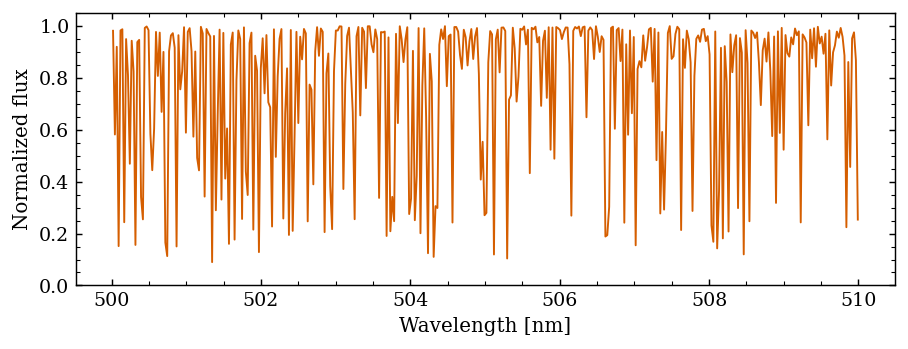

In [6]:
fig, ax = plt.subplots(figsize=(7.1, 2.8))
ax.plot(solar_spectrum.wavelength_nm, solar_spectrum.normalized_flux, color=COLORS["payne_zero"])
ax.set(xlabel="Wavelength [nm]", ylabel="Normalized flux", ylim=(0, 1.05))
ax.minorticks_on()
fig.tight_layout()

## 3. Atmosphere plus synthesis

The previous section held the atmosphere fixed. We now supply stellar labels and calculate the depth structure itself. Payne Zero uses a learned initializer to provide a nearby starting atmosphere, then iterates the equation of state, opacity, radiative transfer, convection, and temperature structure until the physical convergence tests pass.

The five-label interface uses effective temperature, surface gravity, metallicity, alpha enhancement, and microturbulence. The initializer only shortens the route to convergence; the archive returned below is produced by the physical atmosphere solver.

In [7]:
from payne_zero_atmosphere import solve_structured_atmosphere

solved_atmosphere = output_dir / "solar_atmosphere" / "payne_zero_structured_atmosphere.npz"
if not solved_atmosphere.is_file():
    solved_atmosphere = solve_structured_atmosphere(
        effective_temperature=5777.0,
        log_surface_gravity=4.44,
        metallicity=0.0,
        alpha_enhancement=0.0,
        microturbulence_km_s=2.0,
        out_dir=solved_atmosphere.parent,
    )
print(solved_atmosphere.relative_to(repo))

tutorial_output/solar_atmosphere/payne_zero_structured_atmosphere.npz


The converged atmosphere is saved in the same schema used by the bundled example. This common boundary lets synthesis remain unchanged whether an atmosphere came from the package, a new calculation, or an external compatible model.

In [8]:
solved_spectrum = synthesize(
    solved_atmosphere,
    wavelength_start_nm=500.0,
    wavelength_end_nm=510.0,
    resolution=20_000,
    device=device,
    dtype=dtype_name,
)

Overlaying the two spectra is a useful end-to-end check. Small differences are expected because the bundled reference and the newly converged calculation need not follow an identical numerical path.

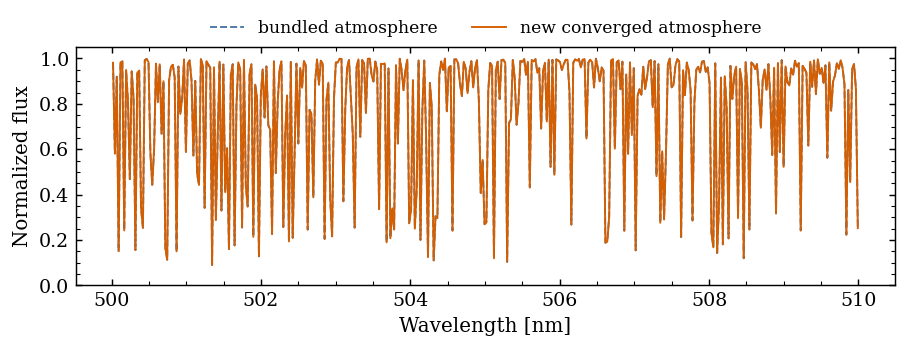

In [9]:
fig, ax = plt.subplots(figsize=(7.1, 2.8))
ax.plot(solar_spectrum.wavelength_nm, solar_spectrum.normalized_flux, color=COLORS["reference"], ls="--", label="bundled atmosphere")
ax.plot(solved_spectrum.wavelength_nm, solved_spectrum.normalized_flux, color=COLORS["payne_zero"], label="new converged atmosphere")
ax.set(xlabel="Wavelength [nm]", ylabel="Normalized flux", ylim=(0, 1.05))
ax.minorticks_on()
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2, borderaxespad=0.2)
fig.tight_layout()

Abundances use the usual logarithmic bracket notation relative to the Sun. The five-label mode varies the overall metal abundance `[M/H]` and a shared alpha-element offset `[alpha/M]`. Adding `[C/M]`, `[N/M]`, and `[O/M]` selects the eight-label mode, which is useful for evolved giants whose surface carbon and nitrogen have changed. The optional direct-abundance initializer accepts individual values such as `[Fe/H]` and `[Mg/H]`. All three modes finish with the same physical solver.

## 4. Differentiable line-list calibration

Atomic transition data are not known perfectly. An incorrect oscillator strength changes a line depth, while damping parameters change the line wings. Because Payne Zero synthesis is expressed as a PyTorch computational graph, these continuous line parameters can be optimized jointly from one or more standard-star spectra.

To keep the mechanics visible, the next example uses two synthetic stars and two trainable oscillator-strength corrections. The interface is the same one used for the Sun and Arcturus calibration, but the analytic profiles finish quickly on a laptop.

In [10]:
from linelist_calibration import calibrate_line_parameters
from linelist_calibration.examples.fit_synthetic_standard_stars import build_example

calibration_data, calibration_config, calibration_model = build_example()
calibration_config = replace(calibration_config, device=device, dtype=dtype_name)

The optimizer changes both line parameters at the same time. Joint optimization matters when features blend, because changing one transition can alter the apparent contribution of another.

In [11]:
calibration = calibrate_line_parameters(
    calibration_data,
    calibration_config,
    calibration_model,
)
dict(zip(calibration.names, calibration.values, strict=True))

{'Fe_I_1569_loggf_dex': 0.08000028133392334,
 'Si_I_1589_loggf_dex': -0.1199992299079895}

The objective is the weighted mean squared flux residual. Its decline shows that the optimizer is making progress, but a production calibration should also inspect representative line profiles to ensure that the improvement is physically sensible.

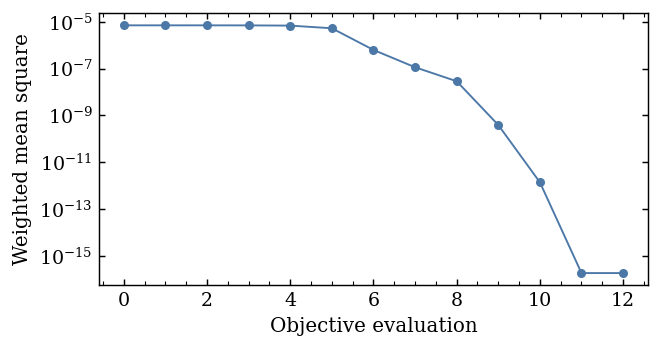

In [12]:
fig, ax = plt.subplots(figsize=(5.2, 2.8))
ax.semilogy(calibration.loss_history, color=COLORS["reference"], marker="o", ms=4)
ax.set(xlabel="Objective evaluation", ylabel="Weighted mean square")
ax.minorticks_on()
fig.tight_layout()

In a physical calibration, Payne Zero synthesis replaces the analytic profiles. The trainable quantities can include oscillator strengths and van der Waals, radiative, and Stark damping parameters. Multiple standard stars enter one objective, allowing a shared line list to be constrained across different temperatures and gravities.

## 5. Controlled normalized-spectrum fit

Before fitting a survey spectrum, it is useful to test the optimizer against known truth. We create a mock normalized spectrum with two absorption lines, a gently tilted continuum, and Gaussian noise. Recovering the injected line depths separates optimization errors from uncertainties in real stellar models or atomic data.

The generic fitter needs an observed spectrum, bounds for each nonlinear parameter, and a function that returns normalized model flux. The two analytic Gaussian profiles below make the relation between the parameters and line depths transparent.

In [13]:
from fitter import FitConfiguration, NormalizedSpectrum, fit_normalized_spectrum

wavelength = np.linspace(500.0, 510.0, 600)
profiles = np.column_stack([
    np.exp(-0.5 * ((wavelength - 503.0) / 0.08) ** 2),
    np.exp(-0.5 * ((wavelength - 507.0) / 0.12) ** 2),
])
def model(p):
    return 1.0 - profiles @ p

Real reductions rarely place the continuum at exactly one. We multiply the mock spectrum by a low-order continuum and add noise with a standard deviation of 0.002 in normalized flux. The fixed random seed makes the example reproducible.

In [14]:
truth = np.array([0.25, 0.12])
coordinate = (wavelength - wavelength.mean()) / np.ptp(wavelength)
continuum_basis = np.column_stack([np.ones(wavelength.size), coordinate])
rng = np.random.default_rng(42)
observed = model(truth) * (1.0 + continuum_basis @ [0.012, -0.006])
observed += rng.normal(0.0, 0.002, wavelength.size)

The inverse variance is `1/σ²`, so precise pixels contribute more to the objective than noisy ones. The mask removes unusable pixels. Parameter bounds define the allowed physical region, finite-difference steps measure local spectral responses, and trust widths prevent one update from moving too far.

In [15]:
mock = NormalizedSpectrum(
    wavelength=wavelength,
    flux=observed,
    inverse_variance=np.full(wavelength.size, 0.002**-2),
    mask=np.ones(wavelength.size, dtype=bool),
)
fit_config = FitConfiguration(
    names=("line_a", "line_b"),
    initial=np.array([0.10, 0.25]),
    lower=np.zeros(2),
    upper=np.full(2, 0.5),
    derivative_steps=np.full(2, 0.01),
    trust_half_width=np.full(2, 0.2),
    maximum_iterations=6,
)

At every trial line depth, the fitter solves the continuum coefficients by weighted linear least squares. This keeps the continuum coupled to the spectrum without treating its coefficients as additional nonlinear labels.

In [16]:
mock_fit = fit_normalized_spectrum(
    mock,
    fit_config,
    model,
    continuum_basis=continuum_basis,
)
print("truth:", truth)
print("fit:  ", mock_fit.parameters)

truth: [0.25 0.12]
fit:   [0.24916189 0.12026328]


The upper panel compares the recovered model with the noisy observation. The lower panel shows data minus model; residuals that fluctuate within the one-sigma band and lack coherent line-shaped structure indicate a successful recovery.

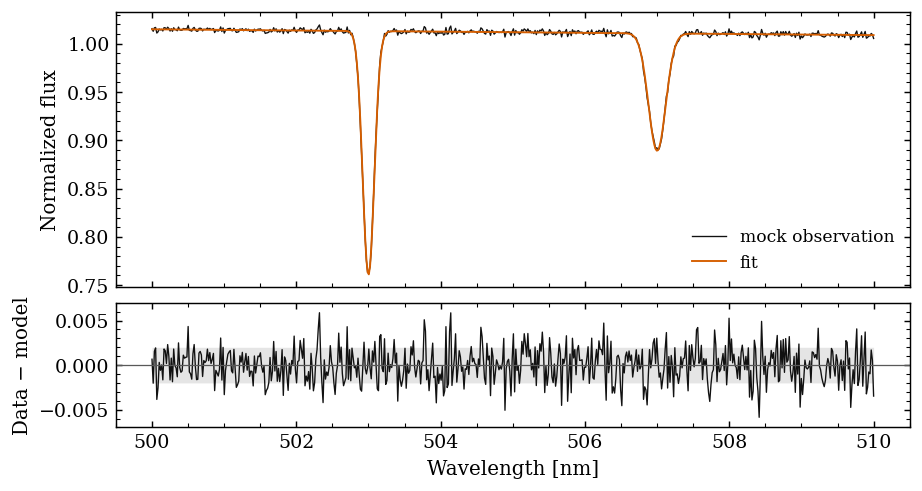

In [17]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(7.1, 3.8), sharex=True, gridspec_kw={"height_ratios": [2.2, 1], "hspace": 0.08})
top.plot(wavelength, observed, color=COLORS["observed"], lw=0.75, label="mock observation")
top.plot(wavelength, mock_fit.model_flux, color=COLORS["payne_zero"], label="fit")
top.set_ylabel("Normalized flux")
top.legend(loc="lower right")
residual = observed - mock_fit.model_flux
bottom.fill_between(wavelength, -0.002, 0.002, color=COLORS["uncertainty"], alpha=0.35, linewidth=0)
bottom.plot(wavelength, residual, color=COLORS["observed"], lw=0.75)
bottom.axhline(0, color="0.35", lw=0.7)
bottom.set(xlabel="Wavelength [nm]", ylabel="Data − model")
bottom.set_ylim(-0.007, 0.007)
for axis in (top, bottom):
    axis.minorticks_on()
fig.subplots_adjust(left=0.12, right=0.98, bottom=0.14, top=0.98)

## 6. APOGEE spectrum with LSF, kinematics, and continuum

A real survey fit adds an instrument model and nuisance parameters to the stellar spectrum. APOGEE records near-infrared light on three detector chips. Its wavelength-dependent line-spread function (LSF) describes how the instrument broadens a monochromatic input, while a residual radial velocity shifts the spectrum and macroscopic broadening accounts for unresolved stellar and instrumental width.

The bundled Data Release 14 example contains 7,514 retained pixels, inverse variances, a quality mask, starting stellar labels, and a mean LSF. The fitter synthesizes an intrinsic spectrum, applies broadening and velocity, convolves with the LSF, samples the detector pixels, and profiles one low-order continuum per chip. This compact demonstration fits five atmosphere labels plus velocity and broadening. The paper uses the same instrument path with twelve abundance coordinates and a final converged-atmosphere check.

Load the observation and its metadata separately. The flux arrays describe the measurement, while the metadata provide the starting point for the nonlinear search; they are not treated as immutable truth.

In [18]:
with np.load(data_dir / "apogee_dr14_example.npz", allow_pickle=False) as source:
    apogee = {name: np.asarray(source[name]) for name in source.files}
metadata = json.loads((data_dir / "apogee_dr14_example.json").read_text())
reference_labels = np.array([
    metadata["effective_temperature"],
    metadata["log_surface_gravity"],
    metadata["metallicity"],
    metadata["alpha_enhancement"],
    metadata["microturbulence_km_s"],
])

A broad view checks the detector coverage, chip gaps, continuum placement, and mask before fitting. Narrow absorption features form the line forest from which the stellar parameters and abundances are inferred.

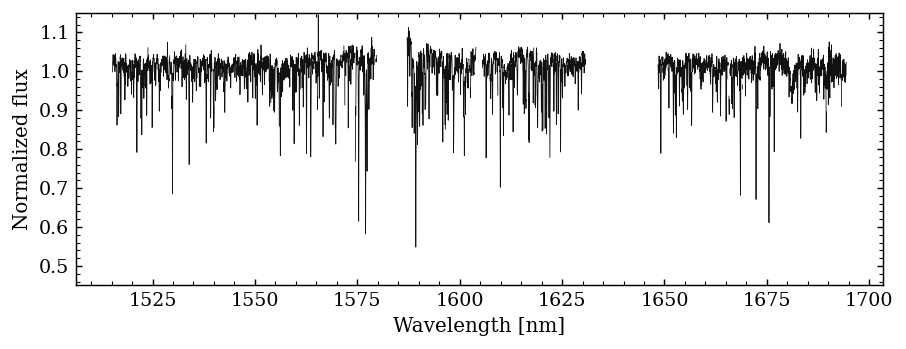

In [19]:
fig, ax = plt.subplots(figsize=(7.1, 2.8))
wavelength_apogee = apogee["wavelength_nm"]
good = apogee["good_pixel_mask"]
visible_flux = np.where(good, apogee["normalized_flux"], np.nan)
chip_edges = np.r_[0, np.flatnonzero(np.diff(wavelength_apogee) > 5.0) + 1, wavelength_apogee.size]
for lower, upper in zip(chip_edges[:-1], chip_edges[1:], strict=True):
    ax.plot(wavelength_apogee[lower:upper], visible_flux[lower:upper], color=COLORS["observed"], lw=0.45)
ax.set(xlabel="Wavelength [nm]", ylabel="Normalized flux", ylim=(0.45, 1.15))
ax.minorticks_on()
fig.tight_layout()

`fit_apogee_spectrum` keeps the stellar and instrumental calculations inside one forward model. Every trial therefore compares the observation with a spectrum that has been shifted, broadened, convolved, sampled, and continuum-profiled in the same way.

In [20]:
from fitter.apogee import fit_apogee_spectrum

apogee_result_dir = output_dir / "apogee_fit"
atomic_calibration = (
    repo / "linelist_calibration" / "data" / "sun_arcturus_fts_hband_shared.npz"
)

Keeping observed arrays and starting labels in a small dictionary makes the provenance of the data explicit. Numerical choices such as device, intrinsic sampling, and continuum order remain separate.

In [21]:
apogee_inputs = {
    "object_id": metadata["object_id"],
    "wavelength_nm": apogee["wavelength_nm"],
    "normalized_flux": apogee["normalized_flux"],
    "inverse_variance": apogee["inverse_variance"],
    "good_pixel_mask": apogee["good_pixel_mask"],
    "reference_labels": reference_labels,
    "reference_vmacro_km_s": metadata["macroscopic_broadening_km_s"],
}

The intrinsic synthesis grid must sample lines more finely than the final APOGEE pixels before convolution. We use `R_grid=50,000` for a portable tutorial. Increasing it changes the numerical fidelity and cost, but not the fitting interface.

In [22]:
apogee_summary = fit_apogee_spectrum(
    apogee_result_dir,
    **apogee_inputs,
    device=device,
    dtype=dtype_name,
    synthesis_r_grid=50_000,
    fresh_jacobian_rounds=0,
    continuum_order=2,
    atomic_calibration_path=atomic_calibration,
    compact_trace=False,
    force=True,
)

The result reports both stellar coordinates and nuisance parameters. The reduced chi-square summarizes residuals relative to the supplied pixel uncertainties; the spectrum itself remains the more informative diagnostic for coherent mismatches.

In [23]:
print("selected parameters")
for name, value in apogee_summary["selected_parameters"].items():
    print(f"  {name}: {value:.5g}")
print(f"reduced chi-square: {apogee_summary['reduced_chi_square']:.3f}")

selected parameters
  effective_temperature: 4630.6
  log_surface_gravity: 2.6572
  metallicity: -0.56669
  alpha_enhancement: 0.1057
  microturbulence_km_s: 2.2556
  residual_rv_km_s: 0.88678
  vmacro_km_s: 3.0293
reduced chi-square: 3.801


The trace records accepted evaluations so the optimization can be audited. We retrieve the selected model using the index stored in the summary rather than assuming that the last attempted evaluation was accepted.

In [24]:
with np.load(apogee_result_dir / "trace" / "optimization_trace.npz", allow_pickle=False) as trace:
    fitted_apogee_flux = trace["normalized_model_flux"][apogee_summary["selected_evaluation"]]

Finally inspect a representative wavelength interval where individual blends are visible. The upper panel compares observation and model. The lower panel places the residual against the reported one-sigma uncertainty, making mismatches larger than the measurement noise easy to identify.

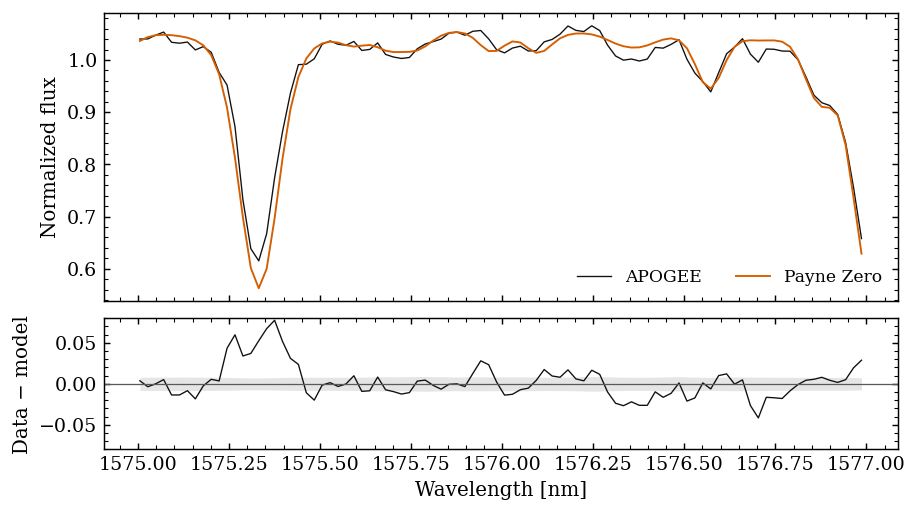

In [25]:
region = (apogee["wavelength_nm"] > 1575.0) & (apogee["wavelength_nm"] < 1577.0) & good
uncertainty = np.zeros_like(apogee["inverse_variance"], dtype=float)
uncertainty[good] = apogee["inverse_variance"][good] ** -0.5
fig, (top, bottom) = plt.subplots(2, 1, figsize=(7.1, 4.0), sharex=True, gridspec_kw={"height_ratios": [2.2, 1], "hspace": 0.08})
top.plot(apogee["wavelength_nm"][region], apogee["normalized_flux"][region], color=COLORS["observed"], lw=0.75, label="APOGEE")
top.plot(apogee["wavelength_nm"][region], fitted_apogee_flux[region], color=COLORS["payne_zero"], label="Payne Zero")
top.legend(loc="lower right", ncol=2)
top.set_ylabel("Normalized flux")
residual = apogee["normalized_flux"] - fitted_apogee_flux
bottom.fill_between(apogee["wavelength_nm"][region], -uncertainty[region], uncertainty[region], color=COLORS["uncertainty"], alpha=0.35, linewidth=0)
bottom.plot(apogee["wavelength_nm"][region], residual[region], color=COLORS["observed"], lw=0.75)
bottom.axhline(0, color="0.35", lw=0.7)
bottom.set(xlabel="Wavelength [nm]", ylabel="Data − model", ylim=(-0.08, 0.08))
for axis in (top, bottom):
    axis.minorticks_on()
fig.subplots_adjust(left=0.12, right=0.98, bottom=0.14, top=0.98)

The production APOGEE analysis uses `R_grid=300,000`, fits twelve abundance coordinates, and checks the selected mixture with a newly converged physical atmosphere. The smaller calculation above is intended to teach the interface. A scientific application should choose its label set, masks, line calibration, intrinsic sampling, and atmosphere checks for the survey at hand; the complete refinement interface is documented in `fitter/README.md`.